<a href="https://colab.research.google.com/github/Kadergueli/conflict-risk-analysis-chad/blob/main/06_risk_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ACLED_CHAD_RESEARCH/data/cleaned_acled_chad.csv')

In [ ]:
# preparation du temps
df['EVENT_DATE'] = pd.to_datetime(df['EVENT_DATE'])

df['year'] = df['EVENT_DATE'].dt.year
df['month'] = df['EVENT_DATE'].dt.month

In [ ]:
# selection des variables
features = [
    'LATITUDE',
    'LONGITUDE',
    'FATALITIES',
    'year',
    'month',
    'EVENT_TYPE',
    'ADMIN1'
]

df_model = df[features].copy()

In [ ]:
#endoder des textes
df_model = df[features].copy() # Re-initialize df_model to ensure original columns are present
df_model = pd.get_dummies(df_model, columns=['EVENT_TYPE', 'ADMIN1'])

In [ ]:
#variables manquantes
df_model = df_model.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Convert 'LATITUDE' and 'LONGITUDE' columns to numeric, replacing comma with dot
for col in ['LATITUDE', 'LONGITUDE']:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace(',', '.', regex=False).astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [ ]:
# clustering propre
from sklearn.cluster import KMeans

model = KMeans(n_clusters=4, random_state=42)
clusters = model.fit_predict(X_scaled)

df['cluster'] = clusters

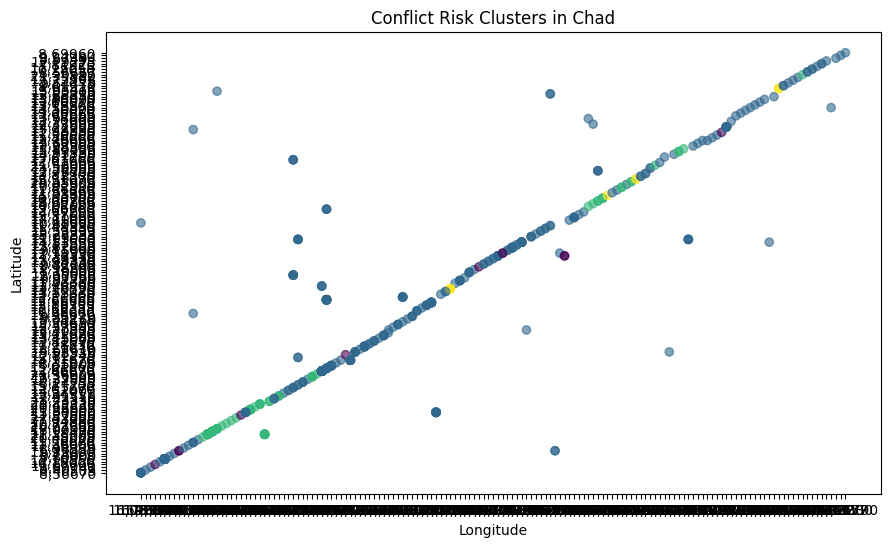

In [ ]:
#visualization en maps
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['LONGITUDE'],
    df['LATITUDE'],
    c=df['cluster'],
    alpha=0.6
)

plt.title("Conflict Risk Clusters in Chad")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
#interpretation du cluster
df.groupby('cluster')['FATALITIES'].mean()


,FATALITIES
cluster,
0,6.545455
1,9.006593
2,17.975000
3,21.750000


In [ ]:
df.groupby('cluster').size()

,0
cluster,
0,11
1,455
2,80
3,12


In [ ]:
df.groupby('cluster')['ADMIN1'].value_counts()

cluster  ADMIN1            
0        Guéra                  11
1        Ouaddaï               210
         Ville de N'Djamena    109
         Wadi Fira              59
         Logone Oriental        17
         Salamat                15
         Moyen-Chari            11
         Mayo-Kebbi Est          6
         Batha                   5
         Logone Occidental       5
         Hadjer-Lamis            4
         Mandoul                 4
         Mayo-Kebbi Ouest        4
         Chari-Baguirmi          3
         Lac                     3
2        Bet                    80
3        Kanem                  12
Name: count, dtype: int64